Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 13,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. While some factors are intuitively understood (e.g., low grades), the relative importance and interaction of various predictors—such as financial stress (tuition vs. loans), academic preparation (High School Grade vs. University GPA), program characteristics (type, level), and student engagement (attendance, extracurricular participation)—are not clearly defined for this specific population.
Specifically, the dataset allows us to investigate key questions that are currently unanswered:
•What is the primary driver of dropout: pre-university academic preparedness (High School Grade), current academic performance (University GPA), or financial constraints (tuition fees, loan availability)?
•How do financial factors (e.g., Tuition_Fees, Student_Loan amount, Scholarship status) interact with academic factors to influence dropout risk?
•Does the impact of these factors vary significantly by student demographics (e.g., Gender, County), the program of study (Program, Program_Level), or levels of engagement (Attendance_Rate, Extracurricular_Participation)?
•Can a predictive model be built to identify students at high risk of dropping out before it happens, based on their first-year or pre-enrollment data?

3. Data Suitability
The provided dataset is well-structured for addressing this problem. It contains:
•Target Variable: A clear binary outcome variable (Dropout), where 1 indicates a student dropped out and 0 indicates they persisted.
•Predictor Variables: A wide range of potential predictors, including:
•Academic: High_School_Grade, University_GPA
•Financial: Scholarship (binary), Tuition_Fees, Student_Loan
•Demographic: Age, Gender, County
•Institutional: Program (e.g., Law, Engineering), Program_Level (e.g., Undergraduate, Postgraduate)
•Engagement: Attendance_Rate (%), Extracurricular_Participation (binary)
•Family Background: Parental_Education_Level
•Scale & Completeness: With over 13,000 records, the dataset has sufficient statistical power to detect meaningful patterns. However, a preliminary check for missing or inconsistent data is necessary before analysis.

4. Objectives of the Analysis
The primary objective is to identify, quantify, and model the key determinants of student dropout in this Kenyan higher education dataset. Specific sub-objectives include:
1.Descriptive Analysis: To profile the student population and compare the characteristics of those who dropped out versus those who persisted, across all academic, financial, demographic, and engagement variables.
2.Exploratory Factor Analysis: To investigate the relationship between independent variables (e.g., Tuition Fees and Student Loan) and the dependent variable (Dropout), and to explore correlations between predictors (e.g., High_School_Grade and University_GPA).
3.Predictive Modeling: To develop and evaluate a classification model (e.g., Logistic Regression, Random Forest, XGBoost) that can accurately predict a student's risk of dropping out based on available data. Feature importance from this model will reveal the most influential factors.
4.Actionable Insights Generation: To translate the findings from the analysis and model into clear, actionable recommendations for university administrators and policymakers. This includes identifying which student segments are most at risk and suggesting targeted interventions (e.g., financial aid restructuring, academic support programs, or engagement initiatives).

5. Expected Outcomes & Impact
A successful analysis will produce:
•A ranked list of the most significant predictors of student dropout in this context.
•A validated predictive model for early identification of at-risk students.
•Data-driven policy recommendations to reduce dropout rates, improve student retention, and optimize the allocation of institutional resources (e.g., targeting financial aid or tutoring to those who need it most).
Ultimately, this analysis aims to contribute to a more efficient and equitable higher education system in Kenya, ensuring that more students who enroll are able to successfully complete their chosen programs.

In [4]:
# Importing the necessary libraries for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')


In [5]:
# Loading the dataset
School_df = pd.read_csv("student.csv")
School_df.head()

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0


In [6]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  float64
 15  

In [7]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

# Assumptions we've made
1. Age - 16yrs and above is eligible to join an Undergrad program
2. 

### Creating some new features in the df

In [8]:
# Creating the Age column

# convert to datetime
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")

# today's date
today = datetime.today()

# create age column
School_df["Age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

In [9]:
columns_to_drop = ['BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED','Loan_serial_number','InstitutionCode', 'Adm No','COURSECODE','INDEXNUMBER','BursaryAllocated','applicanttype', 'Birthdate']

# Use axis=1 to tell pandas these are column names, not row indexes
School_df = School_df.drop(columns_to_drop, axis=1)

School_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Gender              62659 non-null   object 
 1   County              118235 non-null  object 
 2   ScholarshipApplied  118259 non-null  int64  
 3   InstitutionName     118259 non-null  object 
 4   ProgramCost         117794 non-null  float64
 5   CourseCategory      114059 non-null  object 
 6   ExamYear            118259 non-null  int64  
 7   TotalLoanAllocated  118259 non-null  float64
 8   LoanproductCode     118259 non-null  object 
 9   Category            118259 non-null  object 
 10  LoanStatus          118256 non-null  object 
 11  Mother_Age          118259 non-null  int64  
 12  Father_Age          118259 non-null  int64  
 13  Father_educ_level   101442 non-null  object 
 14  Mother_educ_level   97691 non-null   object 
 15  Highest_educ_level  104711 non-nul

In [10]:
School_df.isna().sum()

Gender                55600
County                   24
ScholarshipApplied        0
InstitutionName           0
ProgramCost             465
CourseCategory         4200
ExamYear                  0
TotalLoanAllocated        0
LoanproductCode           0
Category                  0
LoanStatus                3
Mother_Age                0
Father_Age                0
Father_educ_level     16817
Mother_educ_level     20568
Highest_educ_level    13548
Drop_out                  0
Age                       9
dtype: int64

In [11]:
#After careful evaluation, we decided to drop the rows in the columns with missing values

School_df=School_df.dropna(subset=["Gender","County","ProgramCost","CourseCategory",
                                   "Father_educ_level","Mother_educ_level","LoanStatus", "Age"])
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 47647 entries, 0 to 118258
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              47647 non-null  object 
 1   County              47647 non-null  object 
 2   ScholarshipApplied  47647 non-null  int64  
 3   InstitutionName     47647 non-null  object 
 4   ProgramCost         47647 non-null  float64
 5   CourseCategory      47647 non-null  object 
 6   ExamYear            47647 non-null  int64  
 7   TotalLoanAllocated  47647 non-null  float64
 8   LoanproductCode     47647 non-null  object 
 9   Category            47647 non-null  object 
 10  LoanStatus          47647 non-null  object 
 11  Mother_Age          47647 non-null  int64  
 12  Father_Age          47647 non-null  int64  
 13  Father_educ_level   47647 non-null  object 
 14  Mother_educ_level   47647 non-null  object 
 15  Highest_educ_level  47647 non-null  object 
 16  Dro

In [12]:
# 
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df.head(10)

,Gender,County,ScholarshipApplied,InstitutionName,ProgramCost,CourseCategory,ExamYear,TotalLoanAllocated,LoanproductCode,Category,LoanStatus,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out,Age,UniversityType,Sponsored
0,Male,MIGORI,0,TECHNICAL UNIVERSITY OF KENYA,270000.0,EngineeringTechnology,2013,60000.0,UG,PublicUniversityGovtSponsored,Partially Disbursed,69,64,Primary,Primary,Primary,0,30.0,Public,GovtSponsored
4,Male,NAKURU,0,Bugema University,0.0,Humanity,2007,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,58,64,Secondary,Secondary,Secondary,0,38.0,Private,SelfSponsored
6,Male,BUNGOMA,0,Mount Kenya University,111000.0,ICT,2012,40000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,64,66,Artisan,Secondary,Artisan,0,29.0,Private,SelfSponsored
7,Female,BUSIA,0,Mount Kenya University,105000.0,Education,2014,60000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,54,64,Degree,Secondary,Degree,1,31.0,Private,SelfSponsored
10,Male,KIAMBU,0,Zetech University,130600.0,Humanity,2010,45000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,62,Secondary,Primary,Secondary,1,37.0,Private,SelfSponsored
13,Male,NAIROBI,0,Open University of Kenya,105000.0,Humanity,2011,55000.0,UG,PublicUniversitySelfSponsored,Partially Disbursed,63,61,Secondary,Primary,Secondary,0,33.0,Public,SelfSponsored
16,Female,MAKUENI,0,Mount Kenya University,140000.0,LaboratoryTechnology,2013,50000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,56,63,Primary,Secondary,Secondary,0,37.0,Private,SelfSponsored
17,Male,HOMA BAY,0,Mount Kenya University,110000.0,HealthRecordsMgt,2010,50000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,50,67,Secondary,Secondary,Secondary,1,34.0,Private,SelfSponsored
19,Male,HOMA BAY,0,Mount Kenya University,110000.0,Education,2014,50000.0,UG,PrivateUniversityGovtSponsored,Partially Disbursed,55,65,Primary,Primary,Primary,0,29.0,Private,GovtSponsored
22,Male,NYAMIRA,0,Mount Kenya University,111000.0,Humanity,2014,55000.0,UG,PrivateUniversitySelfSponsored,Partially Disbursed,48,55,Secondary,Primary,Secondary,0,29.0,Private,SelfSponsored


In [13]:
School_df = School_df[(School_df['LoanproductCode'] != 'DL6') & 
                      (School_df['LoanproductCode'] != 'VC')]

In [14]:
School_df.shape

(47646, 20)

In [15]:
School_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 47646 entries, 0 to 118258
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              47646 non-null  object 
 1   County              47646 non-null  object 
 2   ScholarshipApplied  47646 non-null  int64  
 3   InstitutionName     47646 non-null  object 
 4   ProgramCost         47646 non-null  float64
 5   CourseCategory      47646 non-null  object 
 6   ExamYear            47646 non-null  int64  
 7   TotalLoanAllocated  47646 non-null  float64
 8   LoanproductCode     47646 non-null  object 
 9   Category            47646 non-null  object 
 10  LoanStatus          47646 non-null  object 
 11  Mother_Age          47646 non-null  int64  
 12  Father_Age          47646 non-null  int64  
 13  Father_educ_level   47646 non-null  object 
 14  Mother_educ_level   47646 non-null  object 
 15  Highest_educ_level  47646 non-null  object 
 16  Dro

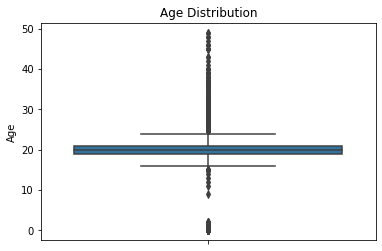

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(y=School_df['Age'])

plt.title('Age Distribution')
plt.show()

# We need to use data from 17 yrs to 22 or 23, that's the data we have, we do not have sufficient data on the rest

In [17]:
School_df= School_df[(School_df['Age'] >= 15) & (School_df['Age'] <= 50)] 

In [18]:
School_df.Age.value_counts()

19.0    16335
20.0    12177
21.0     6410
18.0     5884
22.0     3142
23.0     1387
17.0      750
24.0      551
25.0      260
26.0      164
27.0       88
16.0       73
29.0       53
28.0       52
30.0       35
31.0       34
36.0       33
32.0       32
33.0       17
35.0       15
37.0       12
15.0       10
34.0       10
38.0        8
39.0        7
40.0        4
45.0        3
46.0        3
43.0        2
49.0        2
48.0        2
42.0        1
41.0        1
47.0        1
Name: Age, dtype: int64

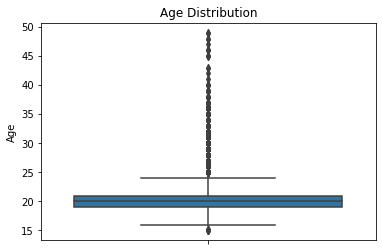

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(y=School_df['Age'])

plt.title('Age Distribution')
plt.show()

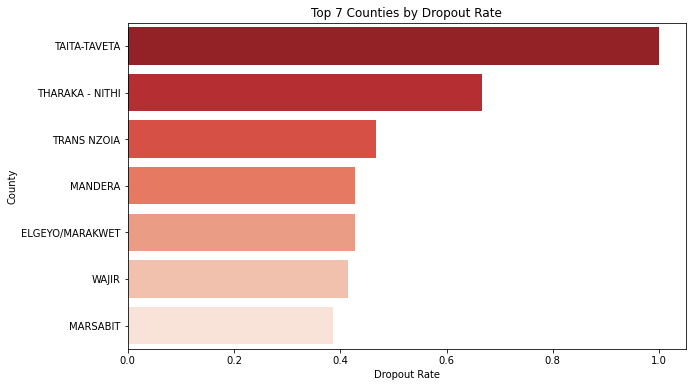

In [20]:
School_df.groupby('County')['Drop_out'].mean().sort_values(ascending=False)
top_counties = (
    School_df.groupby('County')['Drop_out']
    .mean()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(data=top_counties, x='Drop_out', y='County', palette='Reds_r')

plt.title('Top 7 Counties by Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('County')

plt.show()

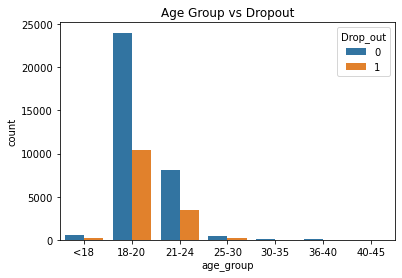

In [21]:
bins = [0, 17, 20, 24, 30, 34, 39, 100]
labels = ['<18', '18-20', '21-24', '25-30', '30-35','36-40','40-45']

School_df['age_group'] = pd.cut(School_df['Age'], bins=bins, labels=labels)    

sns.countplot(x='age_group', hue='Drop_out', data=School_df)

plt.title('Age Group vs Dropout')
plt.show()

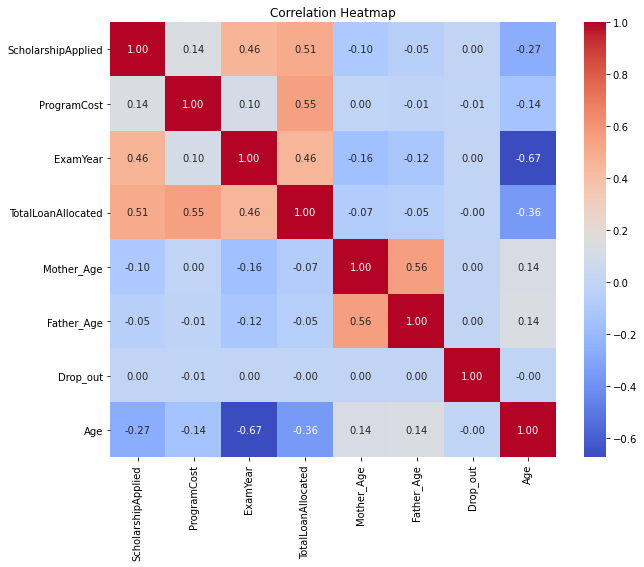

In [22]:
corr = School_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [23]:
# School_df.to_csv('cleaned.csv')

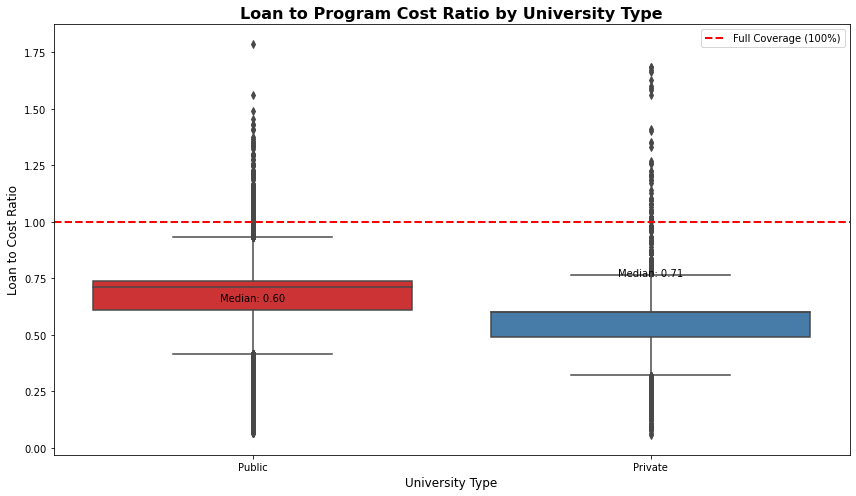

In [24]:
plt.figure(figsize=(12, 7))
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']
# Cap ratio at 2 for better visualization
df_ratio['LoanToCostRatio'] = df_ratio['LoanToCostRatio'].clip(upper=2)

box = sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.title('Loan to Program Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type', fontsize=12)
plt.ylabel('Loan to Cost Ratio', fontsize=12)
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.legend()

stats = df_ratio.groupby('UniversityType')['LoanToCostRatio'].agg(['mean', 'median'])
for i, univ_type in enumerate(stats.index):
    plt.text(i, stats.loc[univ_type, 'median'] + 0.05, 
             f'Median: {stats.loc[univ_type, "median"]:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
count = (School_df['TotalLoanAllocated'] > School_df['ProgramCost']).sum()
print(count) # students who get a higher loan than program cost

2952


This shows What portion of program costs are covered by loans (ratio = Loan Amount / Program Cost), comparing Public vs Private universities.
Public universities has higher ratio due to government support and lower costs compared to Private universities which has lower ratio due to higher fees
Noticeably there are 2952 students who received a higher loan than they needed to cover program cost

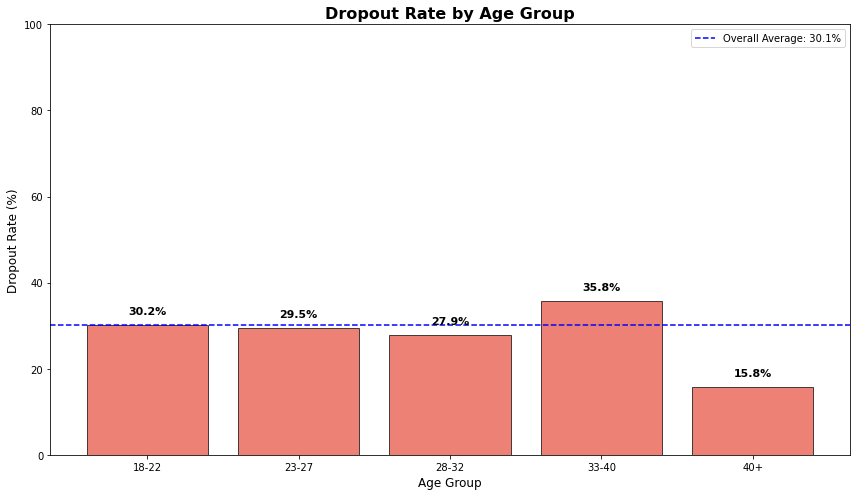

In [47]:
plt.figure(figsize=(12, 7))
df_age_group = School_df.dropna(subset=['Age']).copy()
df_age_group = df_age_group[(df_age_group['Age'] >= 18) & (df_age_group['Age'] <= 60)]

# Create age groups
bins = [18, 22, 27, 32, 40, 100]
labels = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['Age'], bins=bins, labels=labels, right=False)

# Calculate dropout rate by age group
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]  # Filter small groups

bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100, 
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Dropout Rate (%)', fontsize=12)
plt.ylim(0, 100)

# Add percentage labels
for i, (bar, rate) in enumerate(zip(bars, dropout_by_age['mean'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{rate*100:.1f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=df_age_group['Drop_out'].mean() * 100, color='blue', linestyle='--', 
            label=f'Overall Average: {df_age_group["Drop_out"].mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

Age is not a huge determinant in whether a student drops out as the drop out rate is even across the age groups

In [39]:
School_df.Drop_out.value_counts()

0    33258
1    14300
Name: Drop_out, dtype: int64

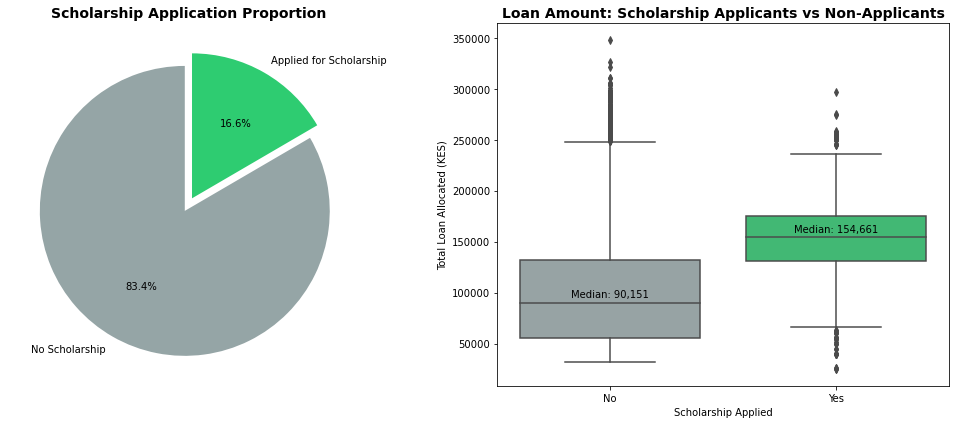

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
labels = ['No Scholarship', 'Applied for Scholarship']
colors_pie = ['#95a5a6', '#2ecc71']
axes[0].pie(scholarship_counts.values, labels=labels, autopct='%1.1f%%', colors=colors_pie, 
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

# Box plot - Loan comparison
sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df, ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship Applicants vs Non-Applicants', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scholarship Applied')
axes[1].set_ylabel('Total Loan Allocated (KES)')
axes[1].set_xticklabels(['No', 'Yes'])

# Add statistics
for i, val in enumerate([0, 1]):
    median_val = School_df[School_df['ScholarshipApplied'] == val]['TotalLoanAllocated'].median()
    axes[1].text(i, median_val + 5000, f'Median: {median_val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Since loans are first assessed and awarded before a student applies for a scholarship, holding a loan becomes a prerequisite for scholarship eligibility. This sequence positions the loan as an initial indicator of financial need. Consequently, students who are awarded scholarships often also have higher loan limits, reinforcing the conclusion that they fall within higher levels of financial need

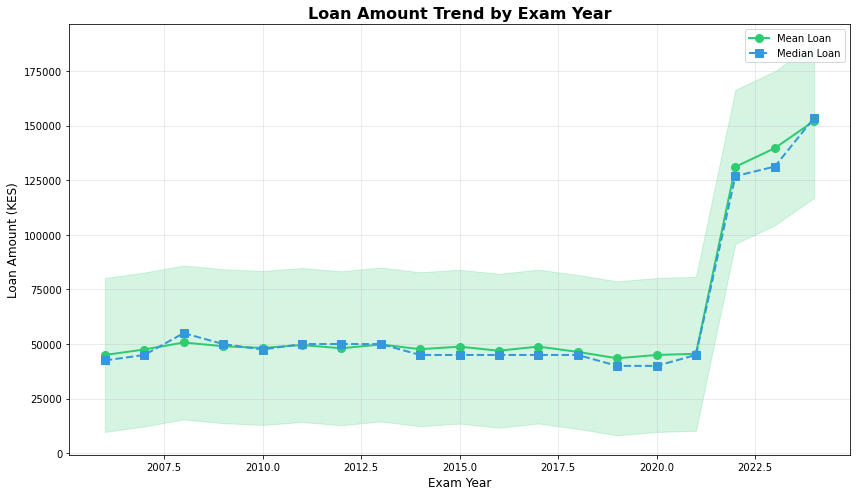

In [28]:
plt.figure(figsize=(12, 7))
year_loan = School_df.groupby('ExamYear')['TotalLoanAllocated'].agg(['mean', 'median', 'count'])
year_loan = year_loan[year_loan['count'] > 5]  # Filter years with few observations

plt.plot(year_loan.index, year_loan['mean'], 'o-', linewidth=2, markersize=8, label='Mean Loan', color='#2ecc71')
plt.plot(year_loan.index, year_loan['median'], 's--', linewidth=2, markersize=8, label='Median Loan', color='#3498db')
plt.fill_between(year_loan.index, year_loan['mean'] - year_loan['mean'].std(), 
                 year_loan['mean'] + year_loan['mean'].std(), alpha=0.2, color='#2ecc71')

plt.title('Loan Amount Trend by Exam Year', fontsize=16, fontweight='bold')
plt.xlabel('Exam Year', fontsize=12)
plt.ylabel('Loan Amount (KES)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



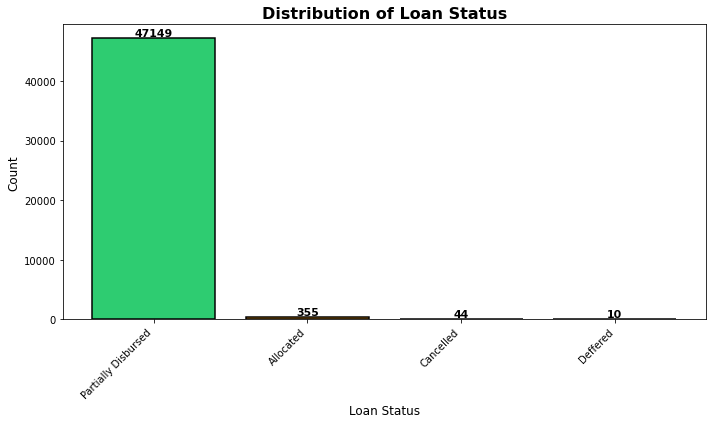

In [29]:
plt.figure(figsize=(10, 6))
status_counts = School_df['LoanStatus'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
bars = plt.bar(status_counts.index, status_counts.values, color=colors[:len(status_counts)], edgecolor='black', linewidth=1.5)
plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar, count in zip(bars, status_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

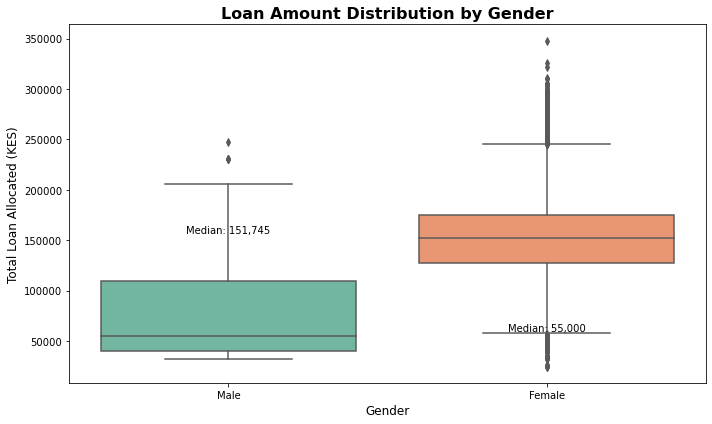

In [30]:
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='Gender', y='TotalLoanAllocated', data=School_df, palette='Set2')
plt.title('Loan Amount Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
# Add median values
medians = School_df.groupby('Gender')['TotalLoanAllocated'].median()
for i, gender in enumerate(medians.index):
    plt.text(i, medians[gender] + 5000, f'Median: {medians[gender]:,.0f}', 
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()



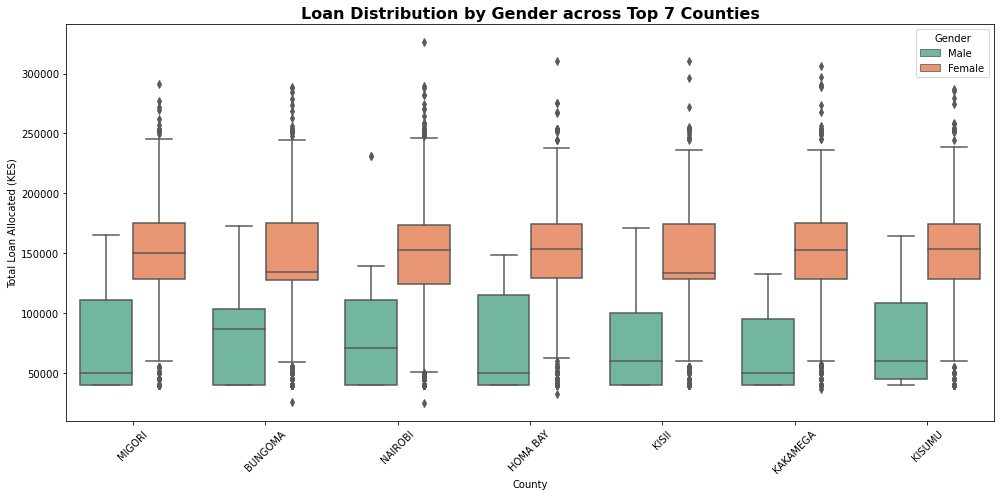

In [51]:
top_counties = (
    School_df['County']
    .value_counts()
    .nlargest(7)
    .index
)

df_top = School_df[School_df['County'].isin(top_counties)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    x='County',
    y='TotalLoanAllocated',
    hue='Gender',
    data=df_top,
    palette='Set2'
)

plt.title('Loan Distribution by Gender across Top 7 Counties', fontsize=16, fontweight='bold')
plt.xlabel('County')
plt.ylabel('Total Loan Allocated (KES)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

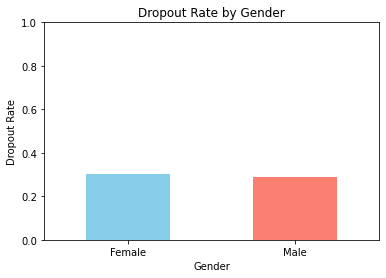

In [50]:
# Calculate dropout rate per gender
dropout_rate = School_df.groupby('Gender')['Drop_out'].mean()

# Plot
dropout_rate.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Dropout Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Dropout Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

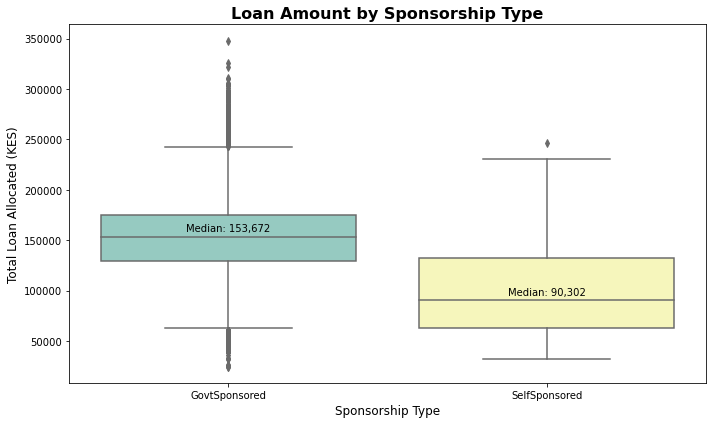

In [31]:
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='Sponsored', y='TotalLoanAllocated', data=School_df, palette='Set3')
plt.title('Loan Amount by Sponsorship Type', fontsize=16, fontweight='bold')
plt.xlabel('Sponsorship Type', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
medians = School_df.groupby('Sponsored')['TotalLoanAllocated'].median()
for i, sponsor in enumerate(medians.index):
    plt.text(i, medians[sponsor] + 5000, f'Median: {medians[sponsor]:,.0f}', 
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Government sponsored is higher than self-sponsored in terms of loan distribution

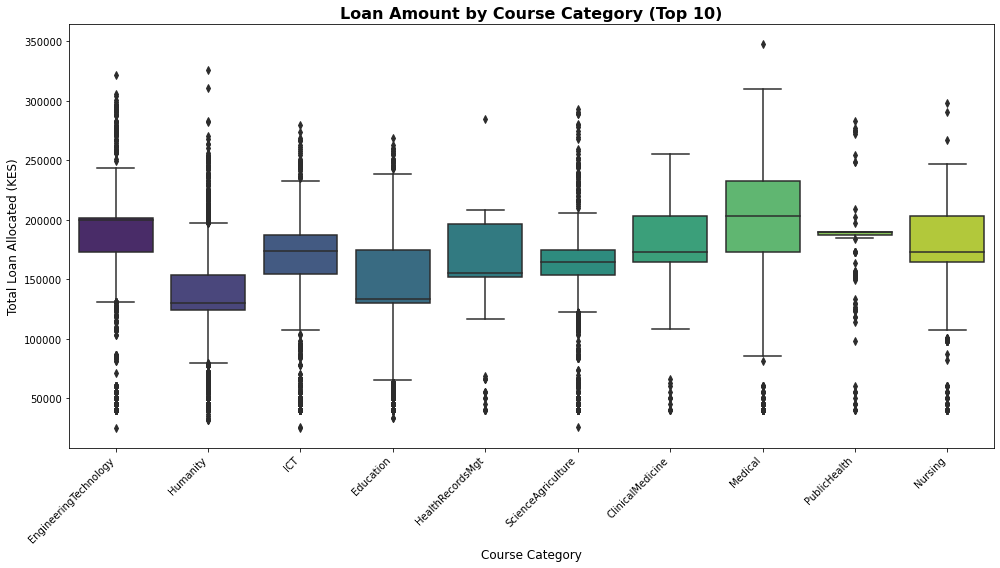

In [33]:
plt.figure(figsize=(14, 8))
# Get top 10 course categories
top_courses = School_df['CourseCategory'].value_counts().head(10).index
df_top_courses = School_df[School_df['CourseCategory'].isin(top_courses)]

box = sns.boxplot(x='CourseCategory', y='TotalLoanAllocated', data=df_top_courses, palette='viridis')
plt.title('Loan Amount by Course Category (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Course Category', fontsize=12)
plt.ylabel('Total Loan Allocated (KES)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Expensive courses tend to get higher loans

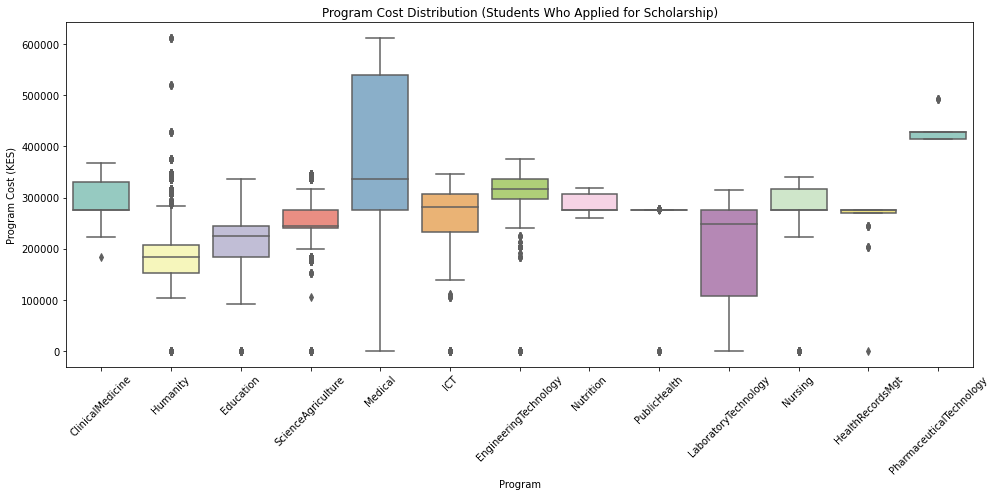

In [54]:
df_applied = School_df[School_df['ScholarshipApplied'] == 1]

plt.figure(figsize=(14, 7))

sns.boxplot(
    x='CourseCategory',
    y='ProgramCost',
    data=df_applied,
    palette='Set3'
)

plt.title('Program Cost Distribution (Students Who Applied for Scholarship)')
plt.xlabel('Program')
plt.ylabel('Program Cost (KES)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This plot supports

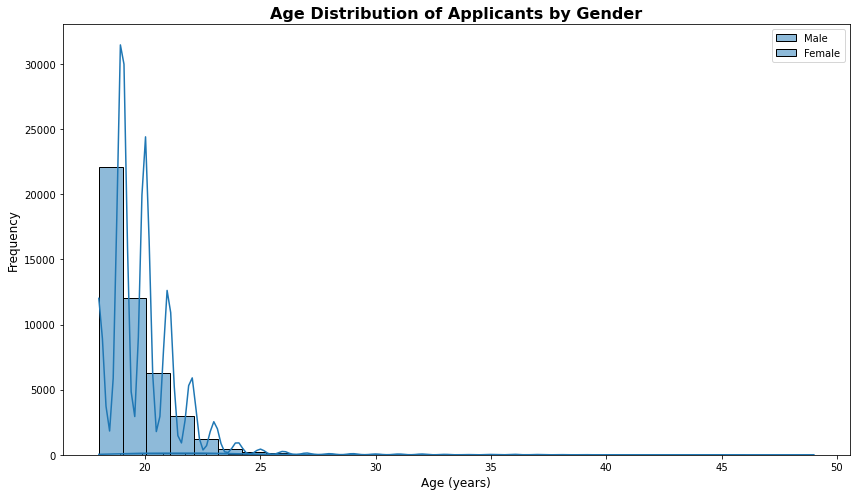

In [34]:
plt.figure(figsize=(12, 7))
df_age = School_df.dropna(subset=['Age', 'Gender'])
# Filter reasonable ages (18-60)
df_age = df_age[(df_age['Age'] >= 18) & (df_age['Age'] <= 60)]

for gender in df_age['Gender'].unique():
    subset = df_age[df_age['Gender'] == gender]
    sns.histplot(subset['Age'], kde=True, label=gender, alpha=0.5, bins=30)

plt.title('Age Distribution of Applicants by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()



<Figure size 720x432 with 0 Axes>

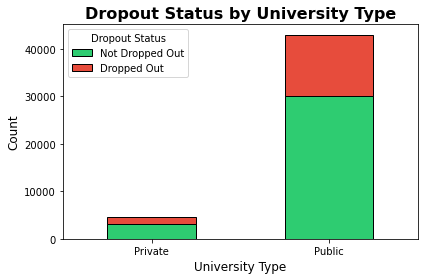

In [35]:
plt.figure(figsize=(10, 6))
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']

dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Dropout Status')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



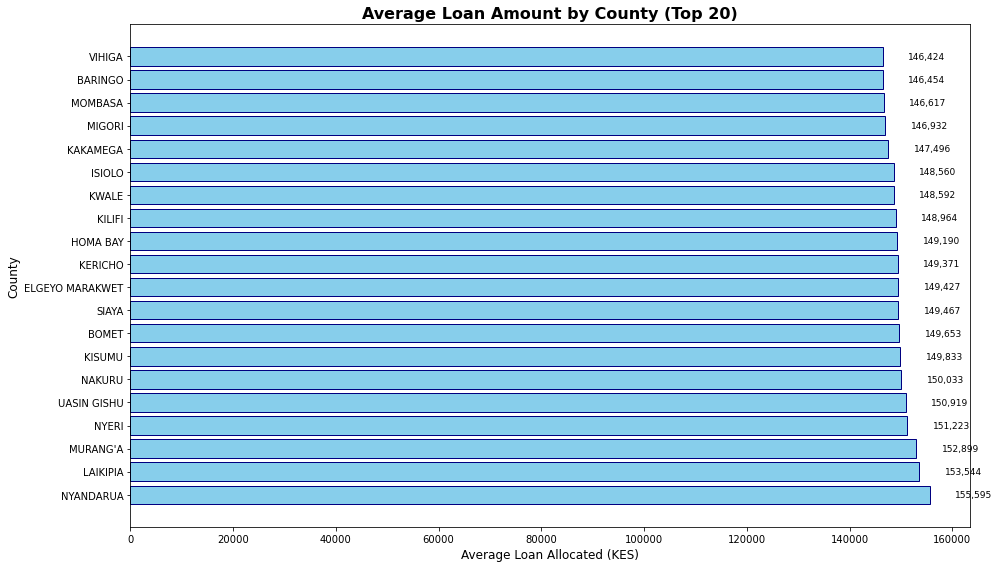

In [36]:
plt.figure(figsize=(14, 8))
county_loan = School_df.groupby('County')['TotalLoanAllocated'].mean().sort_values(ascending=False).head(20)

bars = plt.barh(range(len(county_loan)), county_loan.values, color='skyblue', edgecolor='navy')
plt.title('Average Loan Amount by County (Top 20)', fontsize=16, fontweight='bold')
plt.xlabel('Average Loan Allocated (KES)', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.yticks(range(len(county_loan)), county_loan.index)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, county_loan.values)):
    plt.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

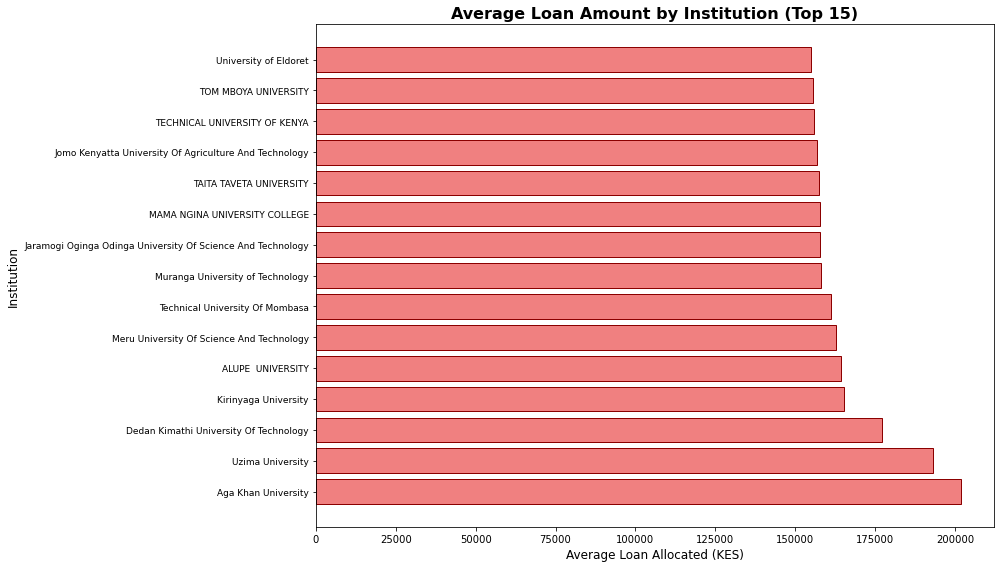

In [37]:
plt.figure(figsize=(14, 8))
inst_loan = School_df.groupby('InstitutionName')['TotalLoanAllocated'].mean().sort_values(ascending=False).head(15)

bars = plt.barh(range(len(inst_loan)), inst_loan.values, color='lightcoral', edgecolor='darkred')
plt.title('Average Loan Amount by Institution (Top 15)', fontsize=16, fontweight='bold')
plt.xlabel('Average Loan Allocated (KES)', fontsize=12)
plt.ylabel('Institution', fontsize=12)
plt.yticks(range(len(inst_loan)), inst_loan.index, fontsize=9)



plt.tight_layout()
plt.show()



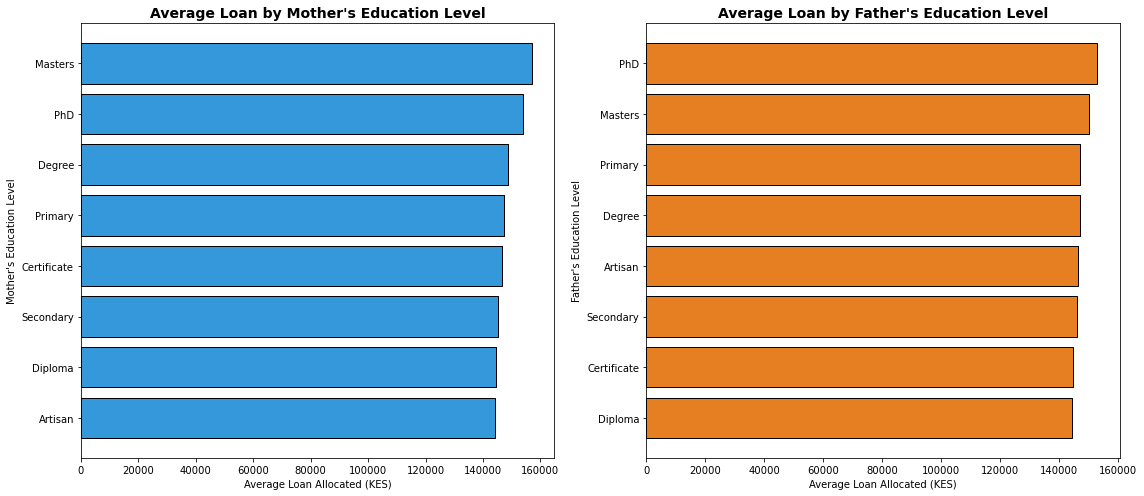

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mother's education
mother_edu = School_df.groupby('Mother_educ_level')['TotalLoanAllocated'].mean().sort_values()
axes[0].barh(mother_edu.index, mother_edu.values, color='#3498db', edgecolor='black')
axes[0].set_title("Average Loan by Mother's Education Level", fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Loan Allocated (KES)')
axes[0].set_ylabel('Mother\'s Education Level')

# Father's education
father_edu = School_df.groupby('Father_educ_level')['TotalLoanAllocated'].mean().sort_values()
axes[1].barh(father_edu.index, father_edu.values, color='#e67e22', edgecolor='black')
axes[1].set_title("Average Loan by Father's Education Level", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Loan Allocated (KES)')
axes[1].set_ylabel('Father\'s Education Level')

plt.tight_layout()
plt.show()



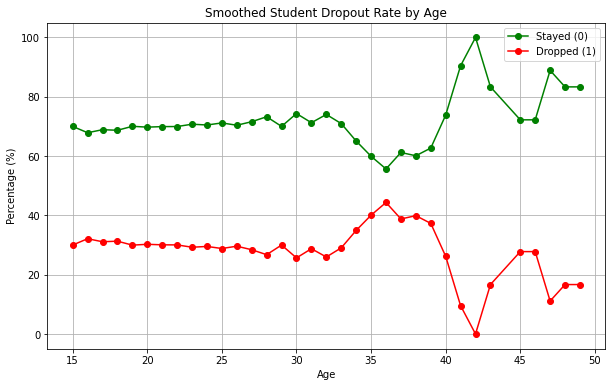

In [43]:
# Group and compute percentages
age_dropout_counts = School_df.groupby(['Age', 'Drop_out']).size().unstack(fill_value=0)
age_dropout_percent = age_dropout_counts.div(age_dropout_counts.sum(axis=1), axis=0) * 100

# Apply rolling mean (smooth)
smoothed = age_dropout_percent.rolling(window=3, min_periods=1).mean()

# Plot
plt.figure(figsize=(10, 6))

plt.plot(smoothed.index, smoothed[0], color='green', marker='o', label='Stayed (0)')
plt.plot(smoothed.index, smoothed[1], color='red', marker='o', label='Dropped (1)')

plt.xlabel('Age')
plt.ylabel('Percentage (%)')
plt.title('Smoothed Student Dropout Rate by Age')
plt.legend()
plt.grid(True)

plt.show()